In [27]:
!pip install pandas numpy scikit-learn nltk spacy seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [28]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PRASHANTH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PRASHANTH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv(r"C:\Users\PRASHANTH\OneDrive\文档\Desktop\FUTURE_TASK_03\DATASET\Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [32]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [33]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [34]:
df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

In [35]:
job_description = """
Looking for a data scientist with experience in Python, machine learning,
data analysis, pandas, numpy, scikit-learn, and visualization.
"""

In [36]:
job_clean = clean_text(job_description)

In [37]:
vectorizer = TfidfVectorizer()

resume_vectors = vectorizer.fit_transform(df['cleaned_resume'])

job_vector = vectorizer.transform([job_clean])

In [38]:
similarity_scores = cosine_similarity(job_vector, resume_vectors)

df['score'] = similarity_scores[0]

In [39]:
ranked_resumes = df.sort_values(by='score', ascending=False)

ranked_resumes[['Resume_str', 'score']].head(10)

,Resume_str,score
926,SOFTWARE DEVELOPER Professi...,0.206174
1339,DATA ANALYST Professional Summa...,0.192911
1218,Pavithra Shetty Summary ...,0.152973
1762,ENGINEERING AND QUALITY TECHNICIAN ...,0.143461
1040,SALES COORDINATOR Summary Cu...,0.077533
1303,SENIOR DIGITAL MARKETING ANALYST ...,0.071264
942,RESEARCH SCIENTIST Summary ...,0.064098
331,MASTER DATA MANAGER Experie...,0.062027
1764,THERMAL ENGINEERING INTERN Summ...,0.059489
2153,"CORPORATE BANKING ASSISTANT, INTERN ...",0.059235


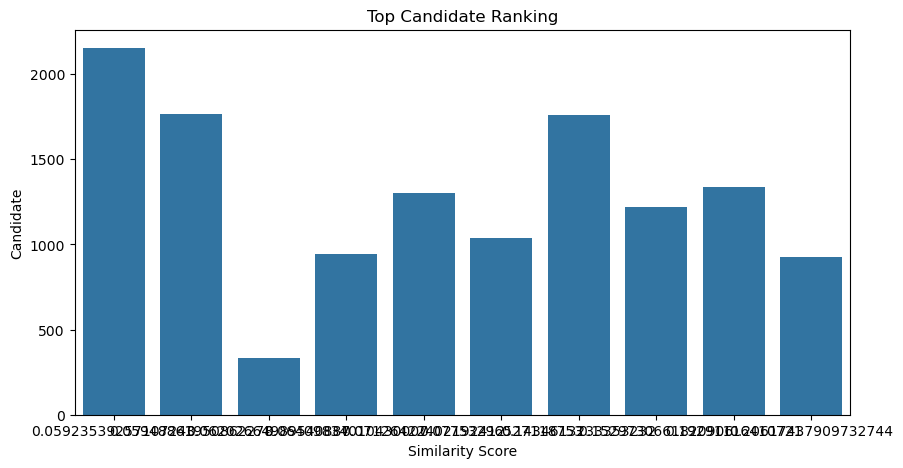

In [40]:
top10 = ranked_resumes.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10['score'], y=top10.index)

plt.title("Top Candidate Ranking")
plt.xlabel("Similarity Score")
plt.ylabel("Candidate")

plt.show()

In [41]:
skills = [
'python','machine learning','deep learning','nlp',
'pandas','numpy','sql','tensorflow','pytorch',
'data analysis','data visualization'
]

In [42]:
def extract_skills(text):

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

In [43]:
df['skills'] = df['cleaned_resume'].apply(extract_skills)

In [44]:
required_skills = ['python','machine learning','pandas','numpy']

def skill_gap(candidate_skills):
    return list(set(required_skills) - set(candidate_skills))

df['missing_skills'] = df['skills'].apply(skill_gap)

In [45]:
print(ranked_resumes.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'cleaned_resume',
       'score'],
      dtype='object')


In [46]:
skills = [
'python','machine learning','deep learning','nlp',
'pandas','numpy','sql','tensorflow','pytorch',
'data analysis','data visualization'
]

def extract_skills(text):

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

df['skills'] = df['cleaned_resume'].apply(extract_skills)

In [47]:
required_skills = ['python','machine learning','pandas','numpy']

def skill_gap(candidate_skills):
    return list(set(required_skills) - set(candidate_skills))

df['missing_skills'] = df['skills'].apply(skill_gap)

In [48]:
ranked_resumes = df.sort_values(by='score', ascending=False)

In [49]:
ranked_resumes[['skills','missing_skills','score']].head(5)

,skills,missing_skills,score
926,"[python, pandas, sql, tensorflow, data visuali...","[machine learning, numpy]",0.206174
1339,"[python, pandas, numpy, sql, data analysis, da...",[machine learning],0.192911
1218,"[python, machine learning, sql, data analysis,...","[numpy, pandas]",0.152973
1762,"[python, machine learning, pandas, sql, data a...",[numpy],0.143461
1040,"[machine learning, data analysis]","[numpy, python, pandas]",0.077533
